In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tifffile

# === Define your folder path ===
data_dir = r"C:\Users\tkpp2\Documents\FISH-ML2\assets\human_in_the_loop\train"

# === Find all matching tif and npy files ===
tif_files = sorted([f for f in os.listdir(data_dir) if f.endswith(".tif")])
npy_files = sorted([f for f in os.listdir(data_dir) if f.endswith(".npy")])

# === Check that each tif has a corresponding seg.npy file ===
paired_files = []
for tif in tif_files:
    base = os.path.splitext(tif)[0]
    npy = base + "_seg.npy"
    if npy in npy_files:
        paired_files.append((tif, npy))
    else:
        print(f"⚠️ Warning: No mask found for {tif}")




In [11]:
# === Inspect shapes before plotting ===
for tif_file, npy_file in paired_files:
    img_path = os.path.join(data_dir, tif_file)
    img = tifffile.imread(img_path)
    
    npy_path = os.path.join(data_dir, npy_file)
    mask = np.load(npy_path, allow_pickle=True)
    
    print(f"{tif_file}: shape={img.shape}, dtype={img.dtype}")
    print(f"{npy_file}: shape={mask.shape}, dtype={mask.dtype}")

    if isinstance(mask, list):
        print(f"  -> mask[0] type: {type(mask[0])}, shape: {getattr(mask[0], 'shape', 'N/A')}")
    elif mask.dtype == object:
        mask_dict = mask.item()
        print(f"  -> mask is a dict with keys: {list(mask_dict.keys())}")
        for k, v in mask_dict.items():
            print(f"     - {k}: type={type(v)}, shape={getattr(v, 'shape', 'N/A')}")

    print("-" * 40)


img_0.tif: shape=(2, 256, 256), dtype=float32
img_0_seg.npy: shape=(), dtype=object
  -> mask is a dict with keys: ['outlines', 'colors', 'masks', 'chan_choose', 'img', 'filename', 'flows', 'ismanual', 'manual_changes', 'model_path']
     - outlines: type=<class 'numpy.ndarray'>, shape=(256, 256)
     - colors: type=<class 'list'>, shape=N/A
     - masks: type=<class 'numpy.ndarray'>, shape=(256, 256)
     - chan_choose: type=<class 'list'>, shape=N/A
     - img: type=<class 'numpy.ndarray'>, shape=(256, 256, 2)
     - filename: type=<class 'str'>, shape=N/A
     - flows: type=<class 'list'>, shape=N/A
     - ismanual: type=<class 'numpy.ndarray'>, shape=(113,)
     - manual_changes: type=<class 'list'>, shape=N/A
     - model_path: type=<class 'str'>, shape=N/A
----------------------------------------
img_1.tif: shape=(2, 256, 256), dtype=float32
img_1_seg.npy: shape=(), dtype=object
  -> mask is a dict with keys: ['outlines', 'colors', 'masks', 'chan_choose', 'img', 'filename', 'flow

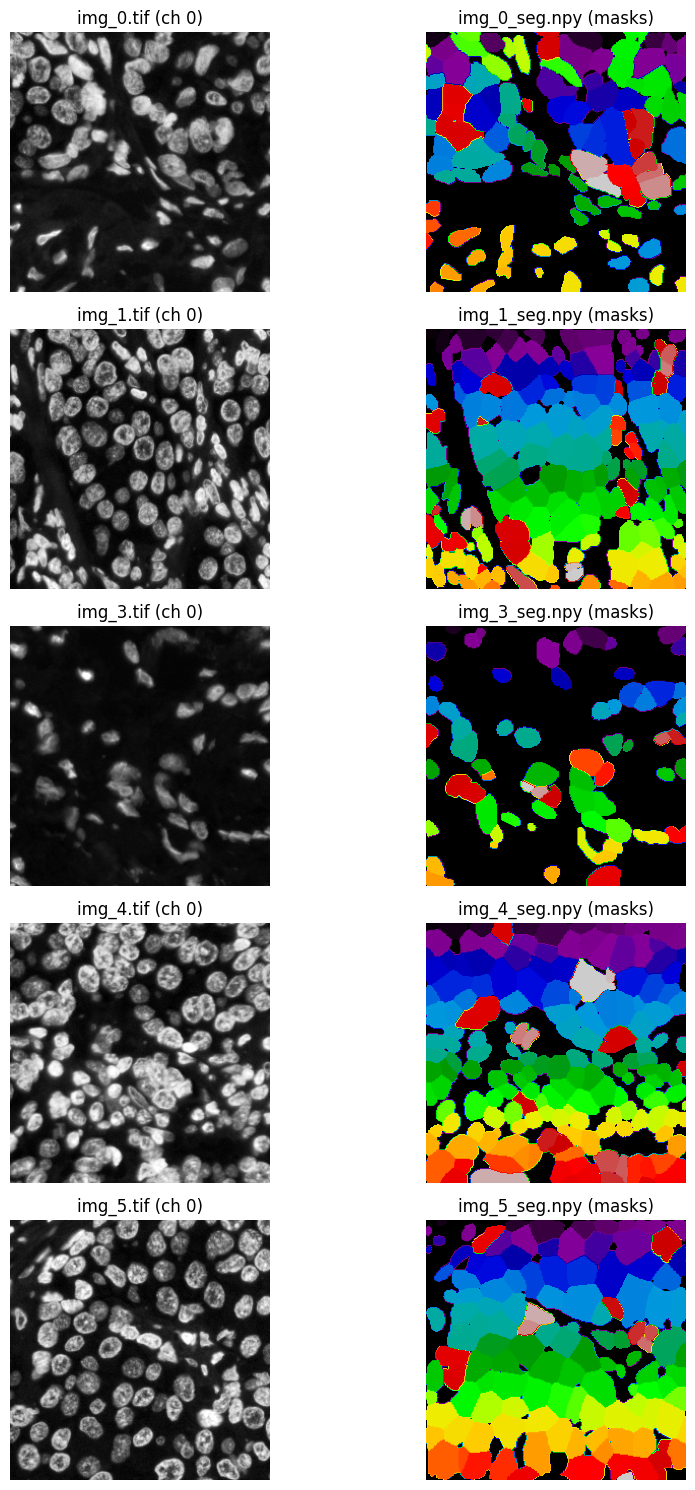

In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tifffile

# === Define your folder path ===
data_dir = r"C:\Users\tkpp2\Documents\FISH-ML2\assets\human_in_the_loop\train"

# === Find all matching tif and npy files ===
tif_files = sorted([f for f in os.listdir(data_dir) if f.endswith(".tif")])
npy_files = sorted([f for f in os.listdir(data_dir) if f.endswith(".npy")])

# === Match files ===
paired_files = []
for tif in tif_files:
    base = os.path.splitext(tif)[0]
    npy = base + "_seg.npy"
    if npy in npy_files:
        paired_files.append((tif, npy))
    else:
        print(f"⚠️ Warning: No mask found for {tif}")

# === Plot ===
n = len(paired_files)
plt.figure(figsize=(10, n * 3))

for idx, (tif_file, npy_file) in enumerate(paired_files):
    # Load raw image
    img = tifffile.imread(os.path.join(data_dir, tif_file))
    img_ch0 = img[0]  # show first channel

    # Load segmentation dict
    seg_dict = np.load(os.path.join(data_dir, npy_file), allow_pickle=True).item()
    mask = seg_dict["masks"]

    # Plot image
    plt.subplot(n, 2, idx * 2 + 1)
    plt.imshow(img_ch0, cmap='gray')
    plt.title(f"{tif_file} (ch 0)")
    plt.axis('off')

    # Plot mask
    plt.subplot(n, 2, idx * 2 + 2)
    plt.imshow(mask, cmap='nipy_spectral')
    plt.title(f"{npy_file} (masks)")
    plt.axis('off')

plt.tight_layout()
plt.show()


Image shape: (256, 256, 2)


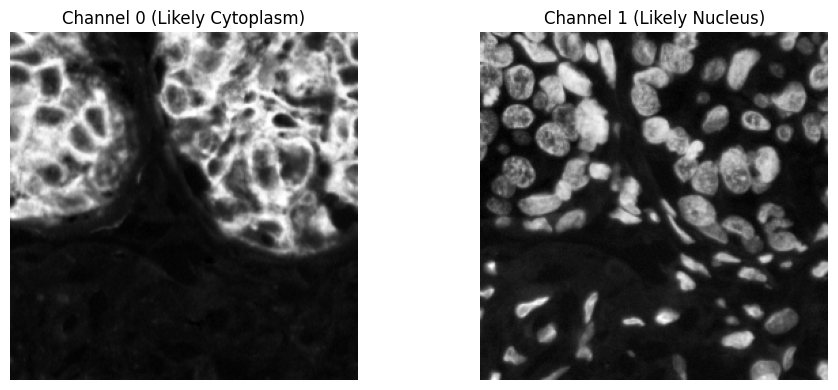

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Update to the full path of one of your sample .npy files
npy_path = r"C:\Users\tkpp2\Documents\FISH-ML2\assets\human_in_the_loop\train\img_0_seg.npy"

# Load the dict (Cellpose-SAM format)
sample = np.load(npy_path, allow_pickle=True).item()
img = sample["img"]  # Shape should be (H, W, 2)

# Confirm shape
print(f"Image shape: {img.shape}")  # Expect (256, 256, 2)

# Plot channels
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img[..., 0], cmap='gray')
plt.title("Channel 0 (Likely Cytoplasm)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img[..., 1], cmap='gray')
plt.title("Channel 1 (Likely Nucleus)")
plt.axis('off')

plt.tight_layout()
plt.show()


## Test with Guohao's data

In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tifffile

# === Define your folder path ===
data_dir = r"C:\Users\tkpp2\Documents\FISH-ML2\assets\cellpose-sam\train"

# === Find all matching tif and npy files ===
tif_files = sorted([f for f in os.listdir(data_dir) if f.endswith(".tif")])
npy_files = sorted([f for f in os.listdir(data_dir) if f.endswith(".npy")])

# === Check that each tif has a corresponding seg.npy file ===
paired_files = []
for tif in tif_files:
    base = os.path.splitext(tif)[0]
    npy = base + "_seg.npy"
    if npy in npy_files:
        paired_files.append((tif, npy))
    else:
        print(f"⚠️ Warning: No mask found for {tif}")




In [15]:
# === Inspect shapes before plotting ===
for tif_file, npy_file in paired_files:
    img_path = os.path.join(data_dir, tif_file)
    img = tifffile.imread(img_path)
    
    npy_path = os.path.join(data_dir, npy_file)
    mask = np.load(npy_path, allow_pickle=True)
    
    print(f"{tif_file}: shape={img.shape}, dtype={img.dtype}")
    print(f"{npy_file}: shape={mask.shape}, dtype={mask.dtype}")

    if isinstance(mask, list):
        print(f"  -> mask[0] type: {type(mask[0])}, shape: {getattr(mask[0], 'shape', 'N/A')}")
    elif mask.dtype == object:
        mask_dict = mask.item()
        print(f"  -> mask is a dict with keys: {list(mask_dict.keys())}")
        for k, v in mask_dict.items():
            print(f"     - {k}: type={type(v)}, shape={getattr(v, 'shape', 'N/A')}")

    print("-" * 40)


img_0.tif: shape=(2048, 2048, 3), dtype=float32
img_0_seg.npy: shape=(), dtype=object
  -> mask is a dict with keys: ['masks', 'img', 'outlines', 'flows', 'ismanual', 'channels']
     - masks: type=<class 'numpy.ndarray'>, shape=(2048, 2048)
     - img: type=<class 'numpy.ndarray'>, shape=(2048, 2048, 3)
     - outlines: type=<class 'numpy.ndarray'>, shape=(2048, 2048)
     - flows: type=<class 'numpy.ndarray'>, shape=(2, 2048, 2048)
     - ismanual: type=<class 'numpy.ndarray'>, shape=(13,)
     - channels: type=<class 'list'>, shape=N/A
----------------------------------------
img_1.tif: shape=(2048, 2048, 3), dtype=float32
img_1_seg.npy: shape=(), dtype=object
  -> mask is a dict with keys: ['masks', 'img', 'outlines', 'flows', 'ismanual', 'channels']
     - masks: type=<class 'numpy.ndarray'>, shape=(2048, 2048)
     - img: type=<class 'numpy.ndarray'>, shape=(2048, 2048, 3)
     - outlines: type=<class 'numpy.ndarray'>, shape=(2048, 2048)
     - flows: type=<class 'numpy.ndarray'>

Image shape: (2048, 2048, 3)


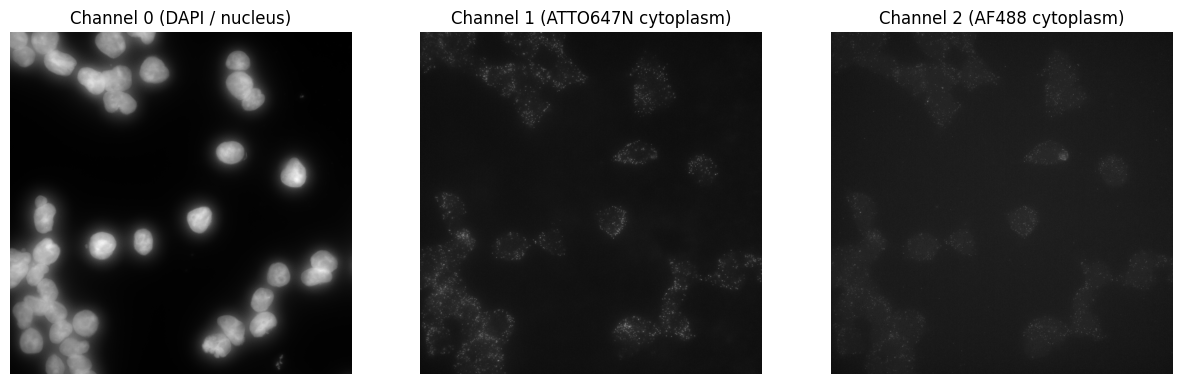

In [19]:
import tifffile as tiff
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

IMG_PATH = Path(r"C:\Users\tkpp2\Documents\FISH-ML2\assets\cellpose-sam\train")

def show_tiff(idx):
    img = tiff.imread(str(IMG_PATH / f"img_{idx}.tif"))
    print("Image shape:", img.shape)

    plt.figure(figsize=(15,5))

    # --- Channel 0 (nucleus) ---
    plt.subplot(1,3,1)
    plt.imshow(img[...,0], cmap="gray")
    plt.title("Channel 0 (DAPI / nucleus)")
    plt.axis("off")

    # --- Channel 1 (cytoplasm/red) ---
    plt.subplot(1,3,2)
    plt.imshow(img[...,1], cmap="gray")
    plt.title("Channel 1 (ATTO647N cytoplasm)")
    plt.axis("off")

    # --- Channel 2 (green) ---
    plt.subplot(1,3,3)
    plt.imshow(img[...,2], cmap="gray")
    plt.title("Channel 2 (AF488 cytoplasm)")
    plt.axis("off")

    plt.show()


show_tiff(0)   # change index as you want


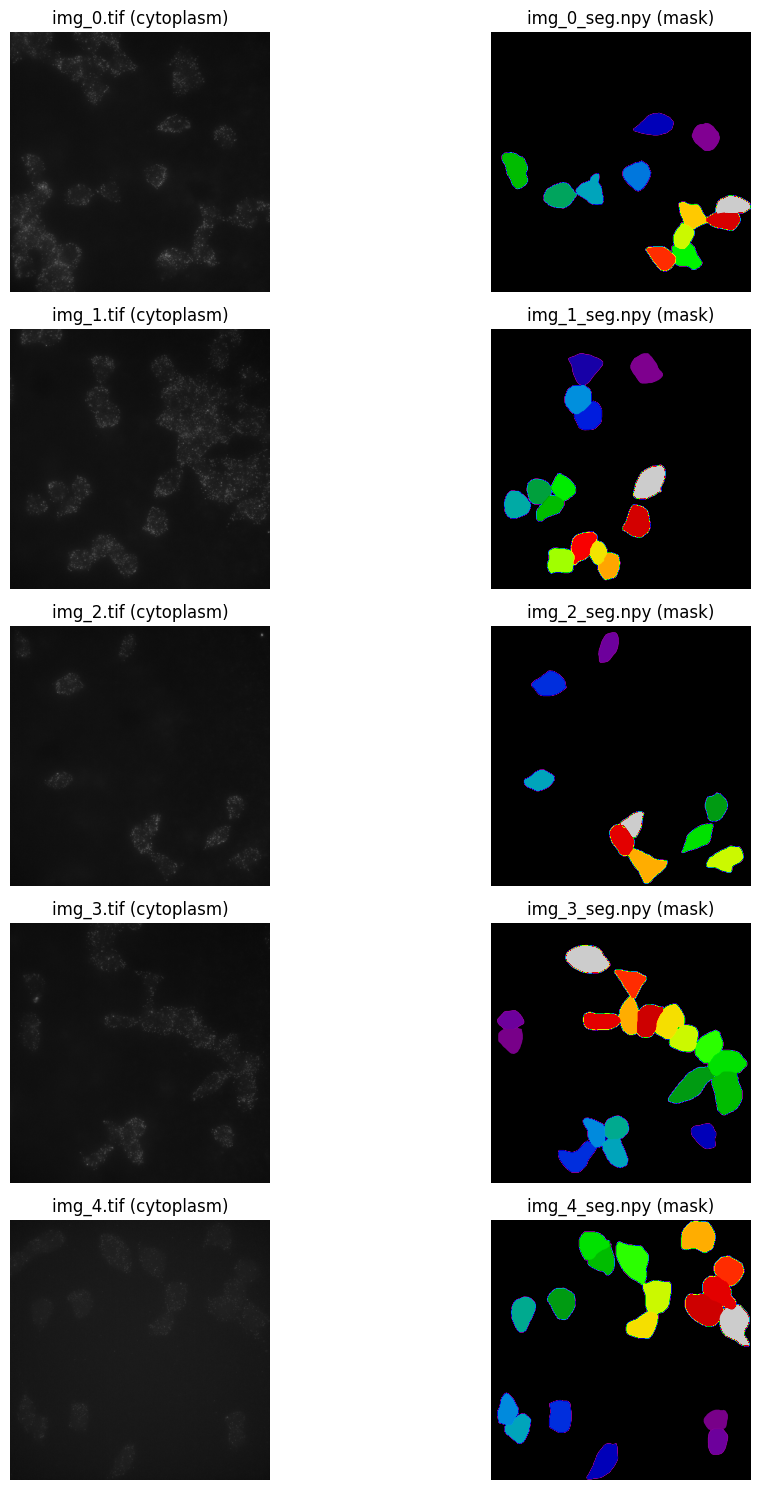

In [21]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tifffile

data_dir = r"C:\Users\tkpp2\Documents\FISH-ML2\assets\cellpose-sam\train"

tif_files = sorted([f for f in os.listdir(data_dir) if f.endswith(".tif")])
npy_files = sorted([f for f in os.listdir(data_dir) if f.endswith(".npy")])

paired_files = []
for tif in tif_files:
    base = os.path.splitext(tif)[0]
    npy = base + "_seg.npy"
    if npy in npy_files:
        paired_files.append((tif, npy))

plt.figure(figsize=(12, len(paired_files) * 3))

for idx, (tif_file, npy_file) in enumerate(paired_files):

    # ---- Load image ----
    img = tifffile.imread(os.path.join(data_dir, tif_file))
    cyto = img[..., 1] if img[...,1].mean() > img[...,2].mean() else img[...,2]

    # ---- Load only masks (avoid huge memory!) ----
    seg_dict = np.load(os.path.join(data_dir, npy_file), allow_pickle=True)
    mask = seg_dict.item().get("masks")   # loads only this key

    # ---- Plot ----
    plt.subplot(len(paired_files), 2, idx * 2 + 1)
    plt.imshow(cyto, cmap="gray")
    plt.title(f"{tif_file} (cytoplasm)")
    plt.axis("off")

    plt.subplot(len(paired_files), 2, idx * 2 + 2)
    plt.imshow(mask, cmap="nipy_spectral")
    plt.title(f"{npy_file} (mask)")
    plt.axis("off")

plt.tight_layout()
plt.show()
